Mapeamento das bases

In [2]:
import os
import pandas as pd

# Caminho da pasta onde estão os CSVs
base_path = r"C:\Users\Eliakim\Downloads\olist_project"

# Listar todas as bases disponíveis na pasta
print("Bases disponíveis:", os.listdir(base_path))

# Carregar as bases principais
orders = pd.read_csv(os.path.join(base_path, "olist_orders_dataset.csv"))
items = pd.read_csv(os.path.join(base_path, "olist_order_items_dataset.csv"))
customers = pd.read_csv(os.path.join(base_path, "olist_customers_dataset.csv"))
payments = pd.read_csv(os.path.join(base_path, "olist_order_payments_dataset.csv"))
reviews = pd.read_csv(os.path.join(base_path, "olist_order_reviews_dataset.csv"))
products = pd.read_csv(os.path.join(base_path, "olist_products_dataset.csv"))
sellers = pd.read_csv(os.path.join(base_path, "olist_sellers_dataset.csv"))
geolocation = pd.read_csv(os.path.join(base_path, "olist_geolocation_dataset.csv"))
translation = pd.read_csv(os.path.join(base_path, "product_category_name_translation.csv"))

# Verificação shape das bases
print("Orders:", orders.shape)
print("Items:", items.shape)
print("Customers:", customers.shape)
print("Payments:", payments.shape)
print("Reviews:", reviews.shape)
print("Products:", products.shape)
print("Sellers:", sellers.shape)
print("Geolocation:", geolocation.shape)
print("Translation:", translation.shape)

# orders.head()
# geolocation.head()

Bases disponíveis: ['olist_customers_dataset.csv', 'olist_geolocation_dataset.csv', 'olist_orders_dataset.csv', 'olist_order_items_dataset.csv', 'olist_order_payments_dataset.csv', 'olist_order_reviews_dataset.csv', 'olist_products_dataset.csv', 'olist_sellers_dataset.csv', 'product_category_name_translation.csv']
Orders: (99441, 8)
Items: (112650, 7)
Customers: (99441, 5)
Payments: (103886, 5)
Reviews: (99224, 7)
Products: (32951, 9)
Sellers: (3095, 4)
Geolocation: (1000163, 5)
Translation: (71, 2)


In [3]:
products.head()

,product_id,product_category_name,product_name_lenght,product_description_lenght,product_photos_qty,product_weight_g,product_length_cm,product_height_cm,product_width_cm
0,1e9e8ef04dbcff4541ed26657ea517e5,perfumaria,40.0,287.0,1.0,225.0,16.0,10.0,14.0
1,3aa071139cb16b67ca9e5dea641aaa2f,artes,44.0,276.0,1.0,1000.0,30.0,18.0,20.0
2,96bd76ec8810374ed1b65e291975717f,esporte_lazer,46.0,250.0,1.0,154.0,18.0,9.0,15.0
3,cef67bcfe19066a932b7673e239eb23d,bebes,27.0,261.0,1.0,371.0,26.0,4.0,26.0
4,9dc1a7de274444849c219cff195d0b71,utilidades_domesticas,37.0,402.0,4.0,625.0,20.0,17.0,13.0


Verificacao das bases

In [4]:
products["product_category_name"].value_counts(normalize=True)

product_category_name
cama_mesa_banho                  0.093658
esporte_lazer                    0.088649
moveis_decoracao                 0.082156
beleza_saude                     0.075570
utilidades_domesticas            0.072199
                                   ...   
fashion_roupa_infanto_juvenil    0.000155
casa_conforto_2                  0.000155
pc_gamer                         0.000093
seguros_e_servicos               0.000062
cds_dvds_musicais                0.000031
Name: proportion, Length: 73, dtype: float64

In [5]:
# Verificar informações gerais de cada base
for name, df in {
    "Orders": orders,
    "Items": items,
    "Customers": customers,
    "Payments": payments,
    "Reviews": reviews,
    "Products": products,
    "Sellers": sellers,
    "Geolocation": geolocation,
    "Translation": translation
}.items():
    print(f"\n{name}")
    print(df.info())
    # print(df.head(2))


Orders
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 99441 entries, 0 to 99440
Data columns (total 8 columns):
 #   Column                         Non-Null Count  Dtype 
---  ------                         --------------  ----- 
 0   order_id                       99441 non-null  object
 1   customer_id                    99441 non-null  object
 2   order_status                   99441 non-null  object
 3   order_purchase_timestamp       99441 non-null  object
 4   order_approved_at              99281 non-null  object
 5   order_delivered_carrier_date   97658 non-null  object
 6   order_delivered_customer_date  96476 non-null  object
 7   order_estimated_delivery_date  99441 non-null  object
dtypes: object(8)
memory usage: 6.1+ MB
None

Items
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 112650 entries, 0 to 112649
Data columns (total 7 columns):
 #   Column               Non-Null Count   Dtype  
---  ------               --------------   -----  
 0   order_id             1126

Estatisticas descritivas

In [ ]:
orders.describe(include="all")
# items.describe(include="all")
# customers.describe(include="all")
# payments.describe(include="all")
# reviews.describe(include="all")
# products.describe(include="all")
# sellers.describe(include="all")
# geolocation.describe(include="all")
# translation.describe(include="all")

Aqui entra um ponto importante. Como o mesmo order_id pode ter mais de 1 compra, decidi criar uma base única na visao cliente, pois o ojetivo da análise é segmentar os usuários, nao os tipos de compras.

Criacao de base unica Visao CPF

In [6]:
import pandas as pd

# 1. Converter datas de string para date
orders["order_purchase_timestamp"] = pd.to_datetime(orders["order_purchase_timestamp"])
orders["order_delivered_customer_date"] = pd.to_datetime(orders["order_delivered_customer_date"])

# 2. Consolidar pedidos por cliente
orders_customer = (
    orders.groupby("customer_id")
    .agg(
        qtde_pedidos=("order_id", "nunique"),
        primeira_compra=("order_purchase_timestamp", "min"),
        ultima_compra=("order_purchase_timestamp", "max")
    )
    .reset_index()
)

# 3. Consolidar pagamentos por cliente
payments_customer = (
    orders[["order_id","customer_id"]]
    .merge(payments, on="order_id", how="left")
    .groupby("customer_id")
    .agg(
        ticket_total=("payment_value","sum"),
        ticket_medio=("payment_value","mean"),
        parcelas_medias=("payment_installments","mean")
    )
    .reset_index()
)

# 4. Consolidar entregas por cliente
orders["tempo_entrega"] = (orders["order_delivered_customer_date"] - orders["order_purchase_timestamp"]).dt.days
entrega_cliente = (
    orders.groupby("customer_id")
    .agg(tempo_entrega_medio=("tempo_entrega","mean"))
    .reset_index()
)

# 5. Consolidar reviews por cliente (precisa trazer customer_id via orders)
reviews_customer = (
    reviews.merge(orders[["order_id","customer_id"]], on="order_id", how="left")
    .groupby("customer_id")
    .agg(
        media_review=("review_score","mean"),
        qtde_reviews=("review_id","count")
    )
    .reset_index()
)

# 6. Consolidar categorias de produto por cliente
items_customer = (
    orders[["order_id","customer_id"]]
    .merge(items, on="order_id", how="left")
    .merge(products[["product_id","product_category_name"]], on="product_id", how="left")
)

categorias_cliente = pd.crosstab(items_customer["customer_id"], items_customer["product_category_name"])
categorias_cliente_prop = categorias_cliente.div(categorias_cliente.sum(axis=1), axis=0).reset_index()

# 7. Construir base final unificada
df_cliente = (
    orders_customer
    .merge(payments_customer, on="customer_id", how="left")
    .merge(entrega_cliente, on="customer_id", how="left")
    .merge(reviews_customer, on="customer_id", how="left")
    .merge(categorias_cliente_prop, on="customer_id", how="left")
)

# 8. Features adicionais
data_max = orders["order_purchase_timestamp"].max()
df_cliente["recencia_dias"] = (data_max - df_cliente["ultima_compra"]).dt.days
df_cliente["frequencia"] = df_cliente["qtde_pedidos"]
df_cliente["valor"] = df_cliente["ticket_total"]
df_cliente["tempo_atividade"] = (df_cliente["ultima_compra"] - df_cliente["primeira_compra"]).dt.days
df_cliente["freq_mensal"] = df_cliente["frequencia"] / (df_cliente["tempo_atividade"]/30 + 1)

Valida duplicidade

In [7]:
# Validação de duplicados
print("Clientes únicos:", df_cliente["customer_id"].nunique())
print("Linhas totais:", len(df_cliente))

duplicados = df_cliente[df_cliente.duplicated(subset=["customer_id"], keep=False)]
print("Duplicados encontrados:", len(duplicados))

Clientes únicos: 99441
Linhas totais: 99441
Duplicados encontrados: 0


Analise descritiva da base unificada

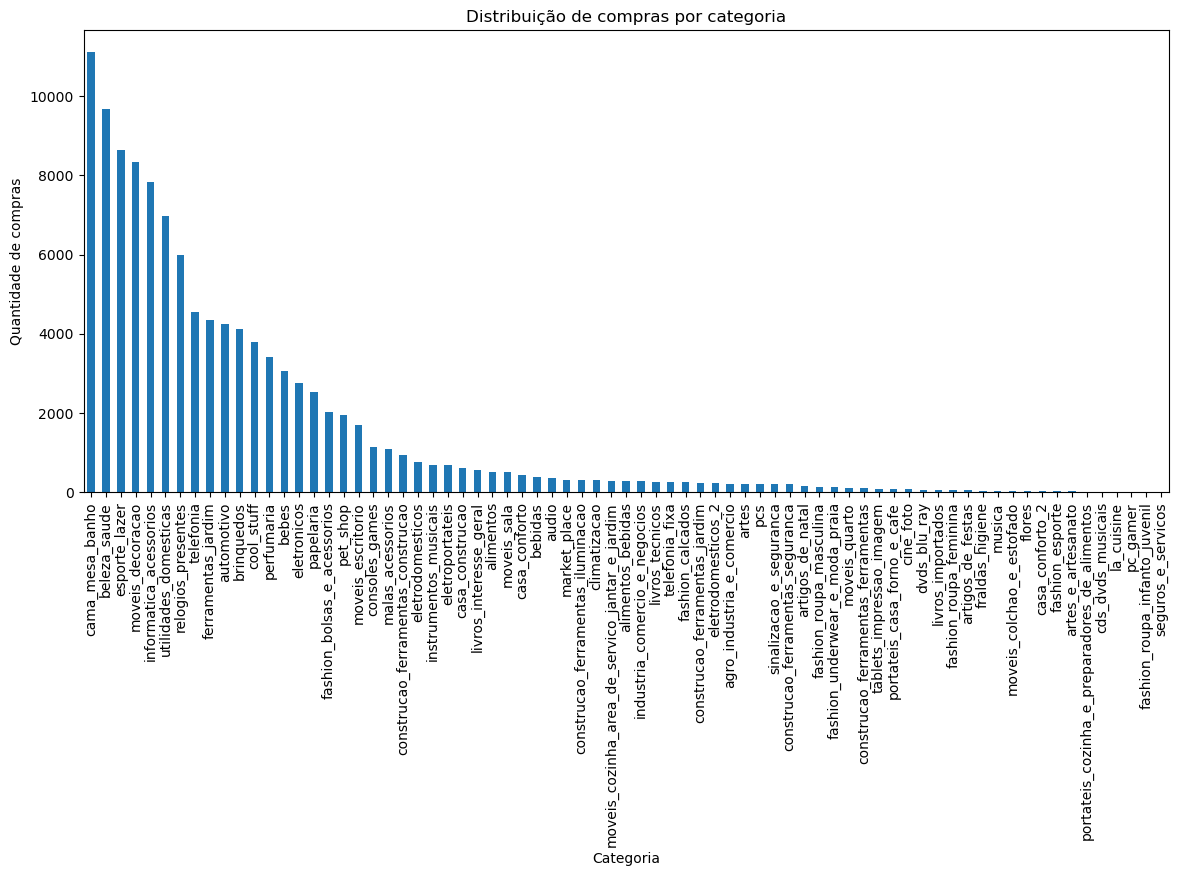

In [8]:
import matplotlib.pyplot as plt

# Contagem total de compras por categoria
cat_counts = items_customer["product_category_name"].value_counts()

plt.figure(figsize=(14,6))
cat_counts.plot(kind="bar")
plt.title("Distribuição de compras por categoria")
plt.xlabel("Categoria")
plt.ylabel("Quantidade de compras")
plt.xticks(rotation=90)
plt.show()

In [ ]:
df_cliente.info()
df_cliente.describe()

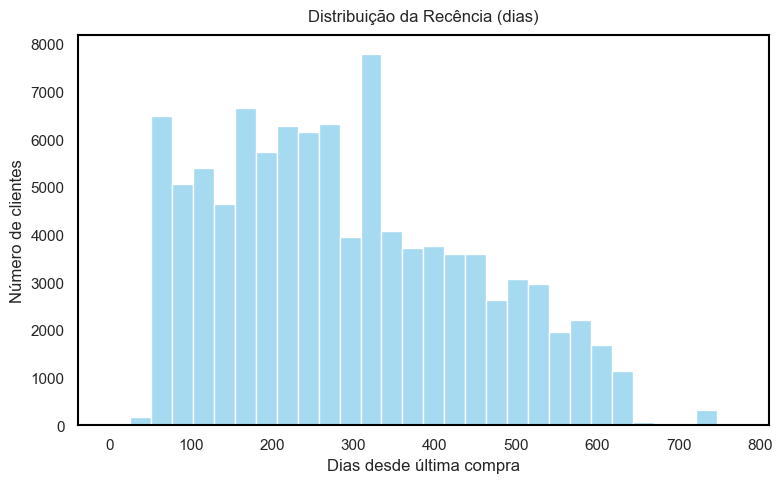

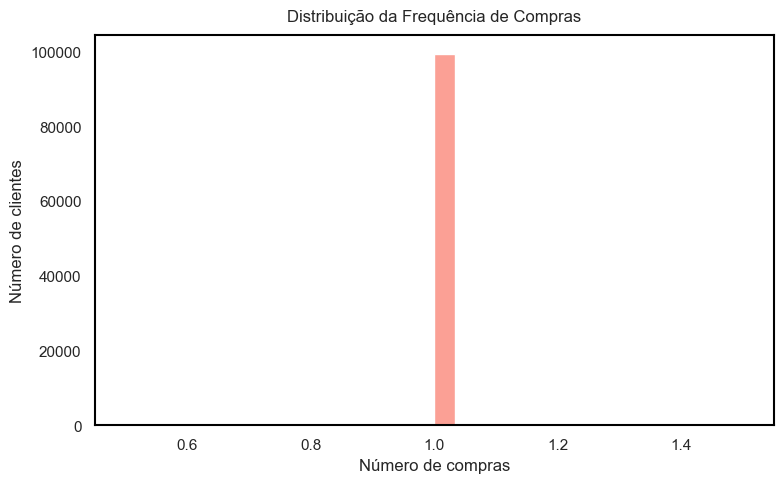

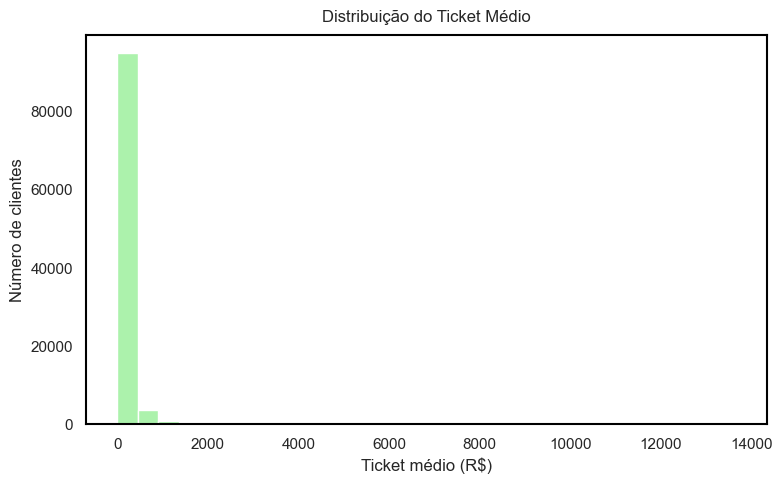

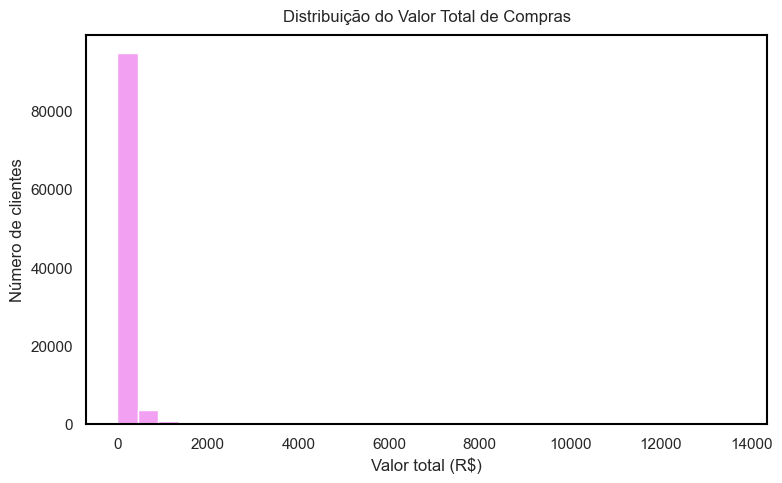

In [21]:
import matplotlib.pyplot as plt
import seaborn as sns
import os

# Definir pasta Downloads
download_path = os.path.expanduser("~/Downloads")

# Configuração global
plt.rcParams.update({
    "font.family": "Arial",       # Fonte Arial
    "axes.edgecolor": "black",    # Cor dos eixos
    "axes.linewidth": 1.5,        # Espessura dos eixos
    "axes.grid": False,           # Sem linhas de grade
    "figure.facecolor": "white"   # Fundo branco
})

# 1. Recência
plt.figure(figsize=(8,5))
sns.histplot(df_cliente["recencia_dias"], bins=30, kde=False, color="skyblue")
plt.title("Distribuição da Recência (dias)", fontsize=12, pad=10)
plt.xlabel("Dias desde última compra")
plt.ylabel("Número de clientes")
plt.tight_layout()
plt.savefig(os.path.join(download_path, "grafico_recencia.png"), dpi=300)
plt.show()

# 2. Frequência
plt.figure(figsize=(8,5))
sns.histplot(df_cliente["frequencia"], bins=30, kde=False, color="salmon")
plt.title("Distribuição da Frequência de Compras", fontsize=12, pad=10)
plt.xlabel("Número de compras")
plt.ylabel("Número de clientes")
plt.tight_layout()
plt.savefig(os.path.join(download_path, "grafico_frequencia.png"), dpi=300)
plt.show()

# 3. Ticket Médio
plt.figure(figsize=(8,5))
sns.histplot(df_cliente["ticket_medio"], bins=30, kde=False, color="lightgreen")
plt.title("Distribuição do Ticket Médio", fontsize=12, pad=10)
plt.xlabel("Ticket médio (R$)")
plt.ylabel("Número de clientes")
plt.tight_layout()
plt.savefig(os.path.join(download_path, "grafico_ticket_medio.png"), dpi=300)
plt.show()

# 4. Valor Total (apenas barras)
plt.figure(figsize=(8,5))
sns.histplot(df_cliente["valor"], bins=30, kde=False, color="violet")
plt.title("Distribuição do Valor Total de Compras", fontsize=12, pad=10)
plt.xlabel("Valor total (R$)")
plt.ylabel("Número de clientes")
plt.tight_layout()
plt.savefig(os.path.join(download_path, "grafico_valor_total.png"), dpi=300)
plt.show()

In [11]:
import numpy as np

# Dicionário de agrupamento (exemplo, pode ajustar conforme necessidade)
mapa_categorias = {
    "alimentos":"alimentos_bebidas",
    "alimentos_bebidas":"alimentos_bebidas",
    "bebidas":"alimentos_bebidas",
    "la_cuisine":"alimentos_bebidas",
    "portateis_casa_forno_e_cafe":"alimentos_bebidas",
    "portateis_cozinha_e_preparadores_de_alimentos":"alimentos_bebidas",
    
    "fashion_bolsas_e_acessorios":"moda",
    "fashion_calcados":"moda",
    "fashion_roupa_feminina":"moda",
    "fashion_roupa_masculina":"moda",
    "fashion_underwear_e_moda_praia":"moda",
    "fashion_roupa_infanto_juvenil":"moda",
    "fashion_esporte":"moda",
    "malas_acessorios":"moda",
    "relogios_presentes":"moda",
    
    "moveis_decoracao":"casa_construcao",
    "moveis_quarto":"casa_construcao",
    "moveis_sala":"casa_construcao",
    "moveis_escritorio":"casa_construcao",
    "cama_mesa_banho":"casa_construcao",
    "utilidades_domesticas":"casa_construcao",
    "casa_conforto":"casa_construcao",
    "casa_conforto_2":"casa_construcao",
    "casa_construcao":"casa_construcao",
    "moveis_colchao_e_estofado":"casa_construcao",
    "moveis_cozinha_area_de_servico_jantar_e_jardim":"casa_construcao",
    "construcao_ferramentas_construcao":"casa_construcao",
    "construcao_ferramentas_ferramentas":"casa_construcao",
    "construcao_ferramentas_iluminacao":"casa_construcao",
    "construcao_ferramentas_jardim":"casa_construcao",
    "construcao_ferramentas_seguranca":"casa_construcao",
    "ferramentas_jardim":"casa_construcao",
    "climatizacao":"casa_construcao",
    "sinalizacao_e_seguranca":"casa_construcao",
    
    "telefonia":"eletronicos",
    "pcs":"eletronicos",
    "pc_gamer":"eletronicos",
    "informatica_acessorios":"eletronicos",
    "eletronicos":"eletronicos",
    "eletrodomesticos":"eletronicos",
    "eletrodomesticos_2":"eletronicos",
    "eletroportateis":"eletronicos",
    "tablets_impressao_imagem":"eletronicos",
    "telefonia_fixa":"eletronicos",
    "consoles_games":"eletronicos",
    "audio":"eletronicos",
    "cine_foto":"eletronicos",
    
    "livros_importados":"livros",
    "livros_tecnicos":"livros",
    "livros_interesse_geral":"livros",
    "papelaria":"livros",
    
    "beleza_saude":"beleza_saude",
    "perfumaria":"beleza_saude",
    
    "bebes":"bebes_pet",
    "fraldas_higiene":"bebes_pet",
    "pet_shop":"bebes_pet",
    
    "esporte_lazer":"esporte_lazer",
    "brinquedos":"esporte_lazer",
    "instrumentos_musicais":"esporte_lazer",
    "musica":"esporte_lazer",
    "flores":"esporte_lazer",

    "artes":"arte_cultura",
    "artes_e_artesanato":"arte_cultura",
    "artigos_de_festas":"arte_cultura",
    "artigos_de_natal":"arte_cultura",
    "cds_dvds_musicais":"arte_cultura",
    "dvds_blu_ray":"arte_cultura",
    "cool_stuff":"arte_cultura",
    "market_place":"arte_cultura",
    
    "agro_industria_e_comercio":"servicos_negocios",
    "industria_comercio_e_negocios":"servicos_negocios",
    "seguros_e_servicos":"servicos_negocios",

    "automotivo":"automotivo",
}

# Criar coluna com macrogrupo
items_customer["macro_categoria"] = items_customer["product_category_name"].map(mapa_categorias).fillna("outros")

# Contagem por macrogrupo
macro_counts = items_customer["macro_categoria"].value_counts()
cum_macro = np.cumsum(macro_counts) / macro_counts.sum() * 100

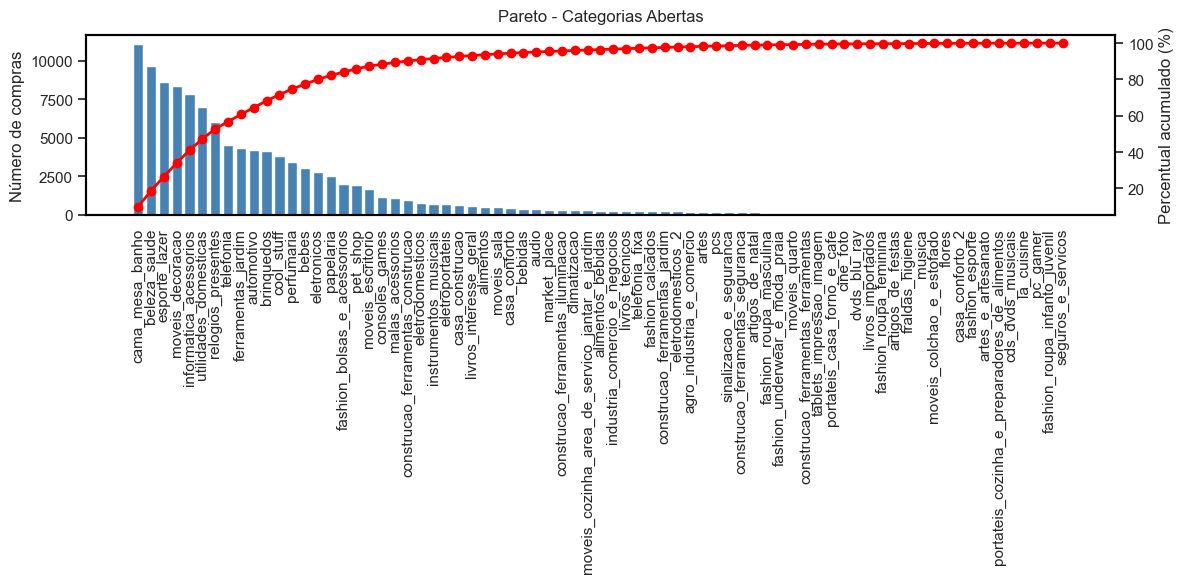

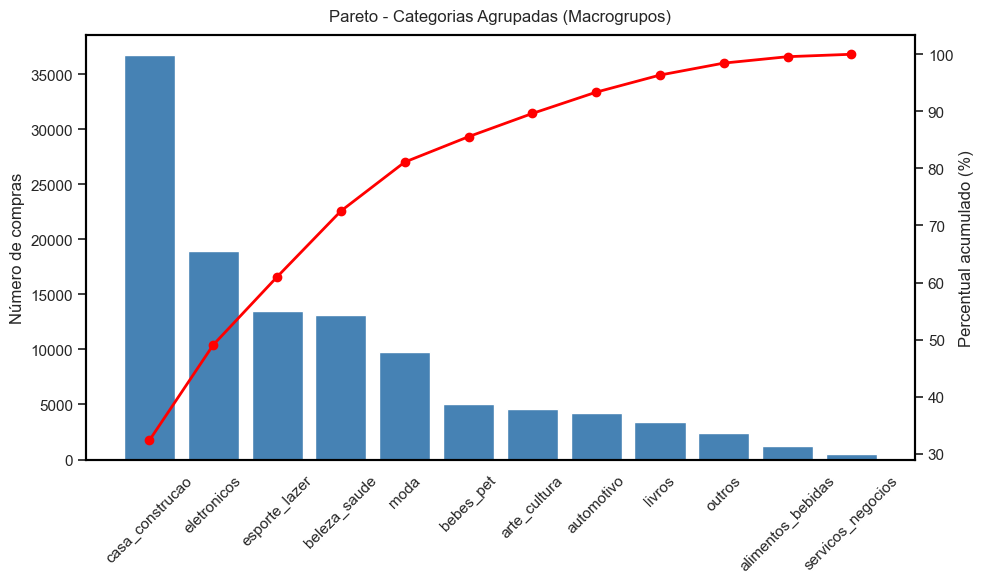

In [23]:
import matplotlib.pyplot as plt
import numpy as np
import os

# Definir pasta Downloads
download_path = os.path.expanduser("~/Downloads")

# Configuração global de estilo
plt.rcParams.update({
    "font.family": "Arial",       # Fonte Arial
    "axes.edgecolor": "black",    # Cor dos eixos
    "axes.linewidth": 1.5,        # Espessura dos eixos
    "axes.grid": False,           # Sem linhas de grade
    "figure.facecolor": "white"   # Fundo branco
})

# -------------------------------
# Pareto - Categorias Abertas
# -------------------------------
cat_counts = items_customer["product_category_name"].value_counts()
cum_percentage = np.cumsum(cat_counts) / cat_counts.sum() * 100

fig, ax1 = plt.subplots(figsize=(12,6))
ax1.bar(cat_counts.index, cat_counts.values, color="steelblue")
ax1.set_ylabel("Número de compras")
ax1.tick_params(axis="x", rotation=90)
ax1.set_title("Pareto - Categorias Abertas", fontsize=12, pad=10)

ax2 = ax1.twinx()
ax2.plot(cat_counts.index, cum_percentage, color="red", marker="o", linewidth=2)
ax2.set_ylabel("Percentual acumulado (%)")

plt.tight_layout()
plt.savefig(os.path.join(download_path, "pareto_categorias_abertas.png"), dpi=300)
plt.show()

# -------------------------------
# Pareto - Macrogrupos
# -------------------------------
macro_counts = items_customer["macro_categoria"].value_counts()
cum_macro = np.cumsum(macro_counts) / macro_counts.sum() * 100

fig, ax3 = plt.subplots(figsize=(10,6))
ax3.bar(macro_counts.index, macro_counts.values, color="steelblue")
ax3.set_ylabel("Número de compras")
ax3.tick_params(axis="x", rotation=45)
ax3.set_title("Pareto - Categorias Agrupadas (Macrogrupos)", fontsize=12, pad=10)

ax4 = ax3.twinx()
ax4.plot(macro_counts.index, cum_macro, color="red", marker="o", linewidth=2)
ax4.set_ylabel("Percentual acumulado (%)")

plt.tight_layout()
plt.savefig(os.path.join(download_path, "pareto_macrogrupos.png"), dpi=300)
plt.show()

Padronizacao de variáveis numéricas e Clusterizacao

In [24]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from sklearn.mixture import GaussianMixture
from sklearn.neighbors import NearestNeighbors
import numpy as np

# 1. Seleção das variáveis numéricas
variaveis_relevantes = ["recencia_dias","frequencia","valor","ticket_medio",
                        "tempo_entrega_medio","media_review"]

X = df_cliente[variaveis_relevantes].fillna(0)

# 2. Padronização
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

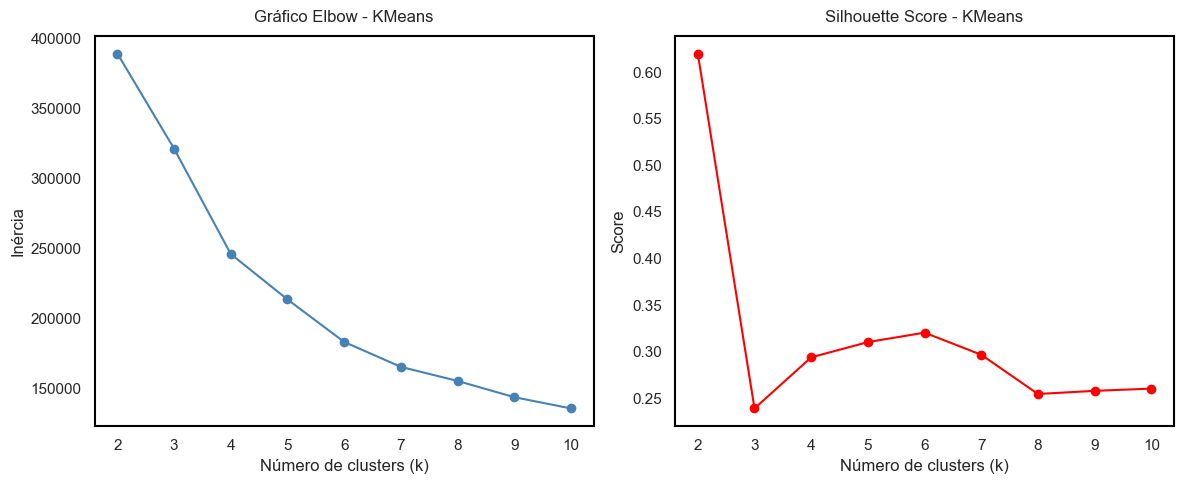

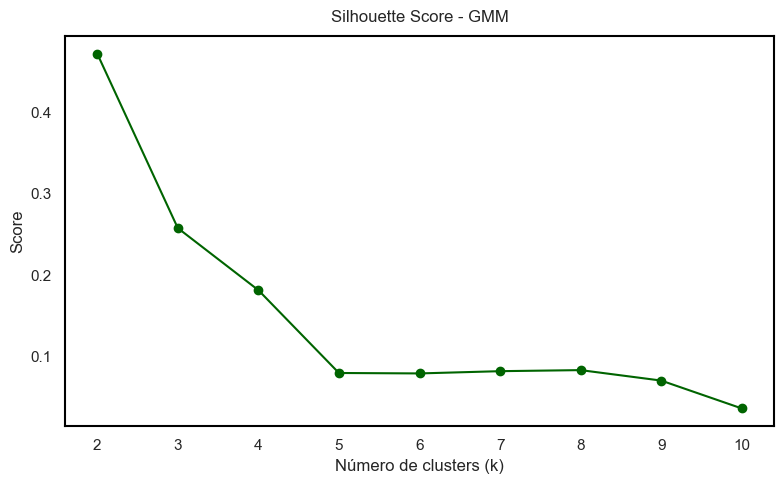

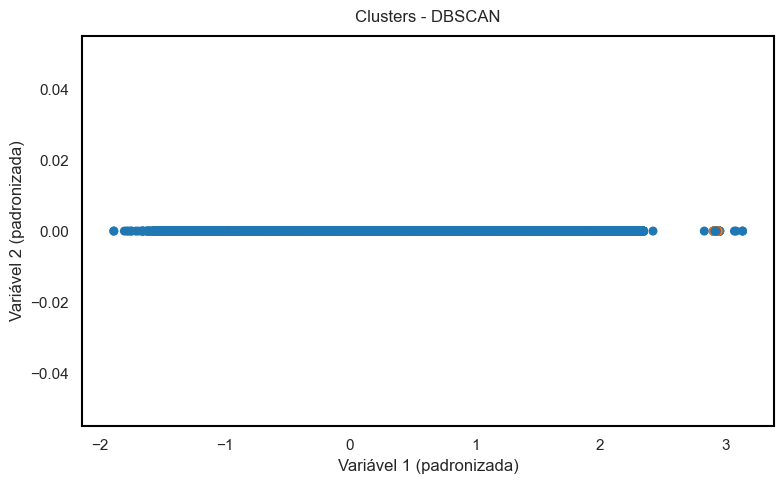

In [25]:
import matplotlib.pyplot as plt
import seaborn as sns
import os
import numpy as np
from sklearn.cluster import KMeans, DBSCAN
from sklearn.mixture import GaussianMixture
from sklearn.metrics import silhouette_score, davies_bouldin_score, calinski_harabasz_score

# Pasta Downloads
download_path = os.path.expanduser("~/Downloads")

# Configuração global
plt.rcParams.update({
    "font.family": "Arial",
    "axes.edgecolor": "black",
    "axes.linewidth": 1.5,
    "axes.grid": False,
    "figure.facecolor": "white"
})

# -------------------------------
# K-MEANS
# -------------------------------
inertia = []
silhouette = []
db_index = []
ch_index = []
K = range(2, 11)

for k in K:
    kmeans = KMeans(n_clusters=k, random_state=42)
    labels = kmeans.fit_predict(X_scaled)
    inertia.append(kmeans.inertia_)
    silhouette.append(silhouette_score(X_scaled, labels))
    db_index.append(davies_bouldin_score(X_scaled, labels))
    ch_index.append(calinski_harabasz_score(X_scaled, labels))

fig, axes = plt.subplots(1, 2, figsize=(12,5))
axes[0].plot(K, inertia, marker="o", color="steelblue")
axes[0].set_title("Gráfico Elbow - KMeans", fontsize=12, pad=10)
axes[0].set_xlabel("Número de clusters (k)")
axes[0].set_ylabel("Inércia")

axes[1].plot(K, silhouette, marker="o", color="red")
axes[1].set_title("Silhouette Score - KMeans", fontsize=12, pad=10)
axes[1].set_xlabel("Número de clusters (k)")
axes[1].set_ylabel("Score")

plt.tight_layout()
plt.savefig(os.path.join(download_path, "kmeans_elbow_silhouette.png"), dpi=300)
plt.show()

# -------------------------------
# GMM
# -------------------------------
silhouette_gmm = []
db_index_gmm = []
ch_index_gmm = []

for k in K:
    gmm = GaussianMixture(n_components=k, random_state=42)
    labels = gmm.fit_predict(X_scaled)
    silhouette_gmm.append(silhouette_score(X_scaled, labels))
    db_index_gmm.append(davies_bouldin_score(X_scaled, labels))
    ch_index_gmm.append(calinski_harabasz_score(X_scaled, labels))

plt.figure(figsize=(8,5))
plt.plot(K, silhouette_gmm, marker="o", color="darkgreen")
plt.title("Silhouette Score - GMM", fontsize=12, pad=10)
plt.xlabel("Número de clusters (k)")
plt.ylabel("Score")
plt.tight_layout()
plt.savefig(os.path.join(download_path, "gmm_silhouette.png"), dpi=300)
plt.show()

# -------------------------------
# DBSCAN
# -------------------------------
dbscan = DBSCAN(eps=0.5, min_samples=5)
labels_db = dbscan.fit_predict(X_scaled)

# Filtrar ruído (-1)
mask = labels_db != -1
if len(set(labels_db)) > 1:
    silhouette_db = silhouette_score(X_scaled[mask], labels_db[mask])
    db_index_db = davies_bouldin_score(X_scaled[mask], labels_db[mask])
    ch_index_db = calinski_harabasz_score(X_scaled[mask], labels_db[mask])
else:
    silhouette_db = None
    db_index_db = None
    ch_index_db = None

plt.figure(figsize=(8,5))
plt.scatter(X_scaled[:,0], X_scaled[:,1], c=labels_db, cmap="tab10", s=30)
plt.title("Clusters - DBSCAN", fontsize=12, pad=10)
plt.xlabel("Variável 1 (padronizada)")
plt.ylabel("Variável 2 (padronizada)")
plt.tight_layout()
plt.savefig(os.path.join(download_path, "dbscan_clusters.png"), dpi=300)
plt.show()

Tabela comparativa entre métodos

In [26]:
import pandas as pd
import os
from sklearn.cluster import KMeans, DBSCAN
from sklearn.mixture import GaussianMixture
from sklearn.metrics import silhouette_score, davies_bouldin_score, calinski_harabasz_score

# Pasta Downloads
download_path = os.path.expanduser("~/Downloads")

# -------------------------------
# K-MEANS
# -------------------------------
results = []
K = range(2, 11)

for k in K:
    kmeans = KMeans(n_clusters=k, random_state=42)
    labels = kmeans.fit_predict(X_scaled)
    results.append({
        "Método": "K-Means",
        "Clusters": k,
        "Silhouette": silhouette_score(X_scaled, labels),
        "Davies-Bouldin": davies_bouldin_score(X_scaled, labels),
        "Calinski-Harabasz": calinski_harabasz_score(X_scaled, labels)
    })

# -------------------------------
# GMM
# -------------------------------
for k in K:
    gmm = GaussianMixture(n_components=k, random_state=42)
    labels = gmm.fit_predict(X_scaled)
    results.append({
        "Método": "GMM",
        "Clusters": k,
        "Silhouette": silhouette_score(X_scaled, labels),
        "Davies-Bouldin": davies_bouldin_score(X_scaled, labels),
        "Calinski-Harabasz": calinski_harabasz_score(X_scaled, labels)
    })

# -------------------------------
# DBSCAN
# -------------------------------
dbscan = DBSCAN(eps=0.5, min_samples=5)
labels_db = dbscan.fit_predict(X_scaled)

mask = labels_db != -1
if len(set(labels_db)) > 1:
    results.append({
        "Método": "DBSCAN",
        "Clusters": len(set(labels_db)) - (1 if -1 in labels_db else 0),
        "Silhouette": silhouette_score(X_scaled[mask], labels_db[mask]),
        "Davies-Bouldin": davies_bouldin_score(X_scaled[mask], labels_db[mask]),
        "Calinski-Harabasz": calinski_harabasz_score(X_scaled[mask], labels_db[mask])
    })
else:
    results.append({
        "Método": "DBSCAN",
        "Clusters": 0,
        "Silhouette": None,
        "Davies-Bouldin": None,
        "Calinski-Harabasz": None
    })

# -------------------------------
# Criar DataFrame e salvar CSV
# -------------------------------
df_results = pd.DataFrame(results)
csv_path = os.path.join(download_path, "comparacao_clusterizadores.csv")
df_results.to_csv(csv_path, index=False)

print(f"Tabela salva em: {csv_path}")
df_results.head(15)  # mostra as primeiras linhas

Tabela salva em: C:\Users\Eliakim/Downloads\comparacao_clusterizadores.csv


,Método,Clusters,Silhouette,Davies-Bouldin,Calinski-Harabasz
0,K-Means,2,0.619708,0.859450,27679.141206
1,K-Means,3,0.239232,1.349344,27264.757045
2,K-Means,4,0.294002,1.096822,33849.317193
3,K-Means,5,0.310355,1.070028,33003.823822
4,K-Means,6,0.320499,1.000900,34052.672276
5,K-Means,7,0.296793,1.030992,33205.576393
6,K-Means,8,0.254721,1.082293,31216.607340
7,K-Means,9,0.258096,1.047949,30508.094458
8,K-Means,10,0.260472,1.033405,29374.012297
9,GMM,2,0.472096,1.931457,11558.778228


K-Means

    Cluster  macro_categoria  Compras
5         0  casa_construcao    14350
6         0      eletronicos     7855
4         0     beleza_saude     5962
17        1  casa_construcao     2178
18        1      eletronicos     1281
21        1             moda      731
29        2  casa_construcao    11774
30        2      eletronicos     5538
31        2    esporte_lazer     5250
42        3      eletronicos      300
41        3  casa_construcao      284
43        3    esporte_lazer       94
53        4  casa_construcao     5752
54        4      eletronicos     2744
55        4    esporte_lazer     1738
65        5  casa_construcao     2376
66        5      eletronicos     1241
64        5     beleza_saude      837


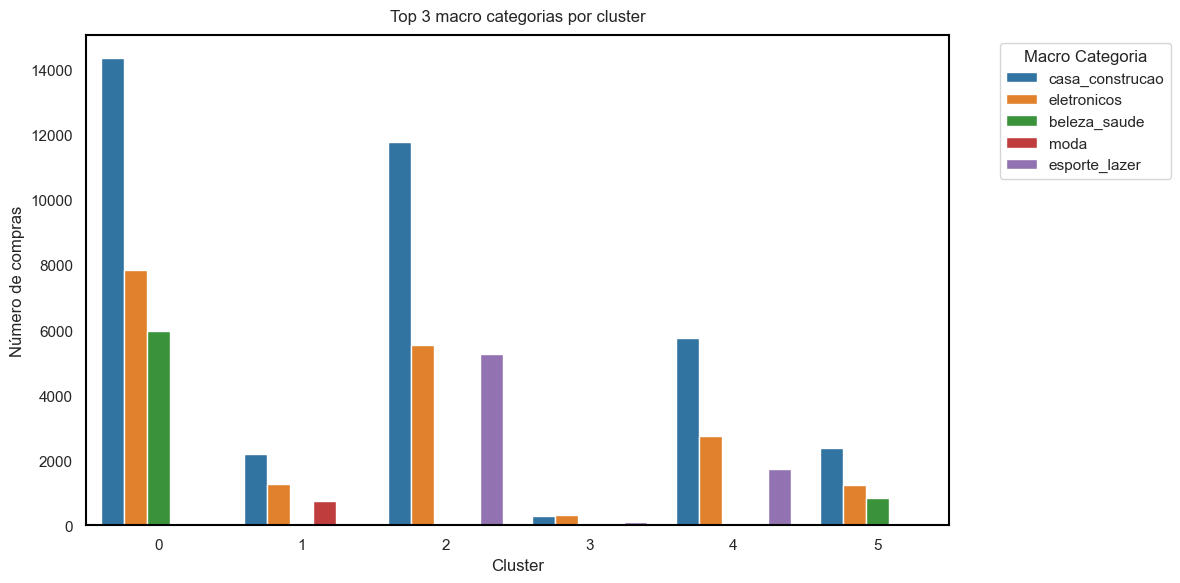

C:\Users\Eliakim\AppData\Local\Temp\ipykernel_15436\3618892919.py:78: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x="Cluster", y=var, data=df_clusters, palette="Set2")


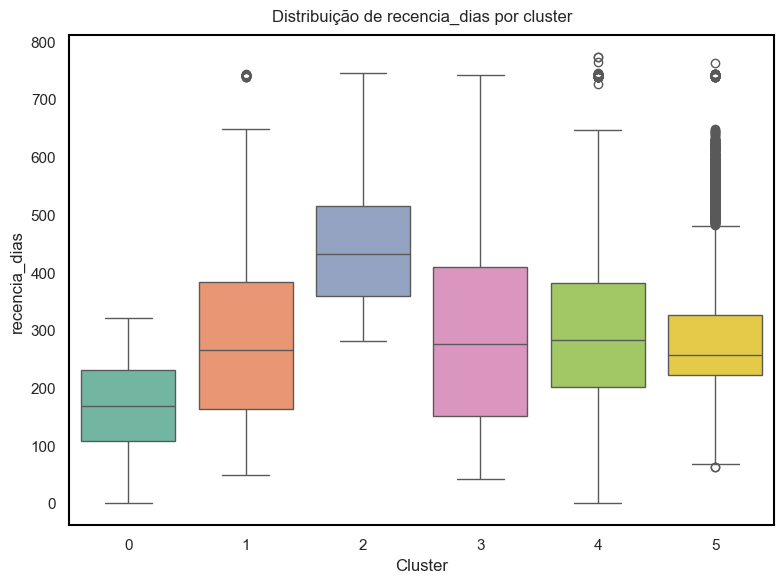

C:\Users\Eliakim\AppData\Local\Temp\ipykernel_15436\3618892919.py:78: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x="Cluster", y=var, data=df_clusters, palette="Set2")


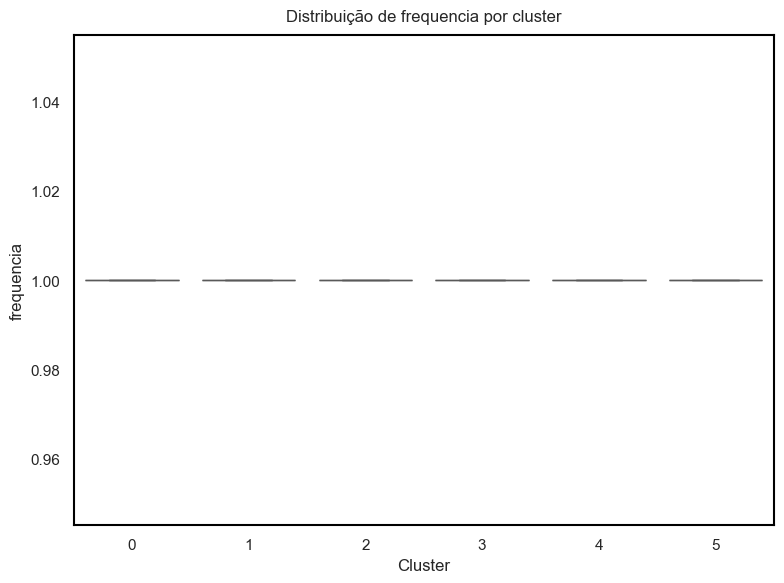

C:\Users\Eliakim\AppData\Local\Temp\ipykernel_15436\3618892919.py:78: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x="Cluster", y=var, data=df_clusters, palette="Set2")


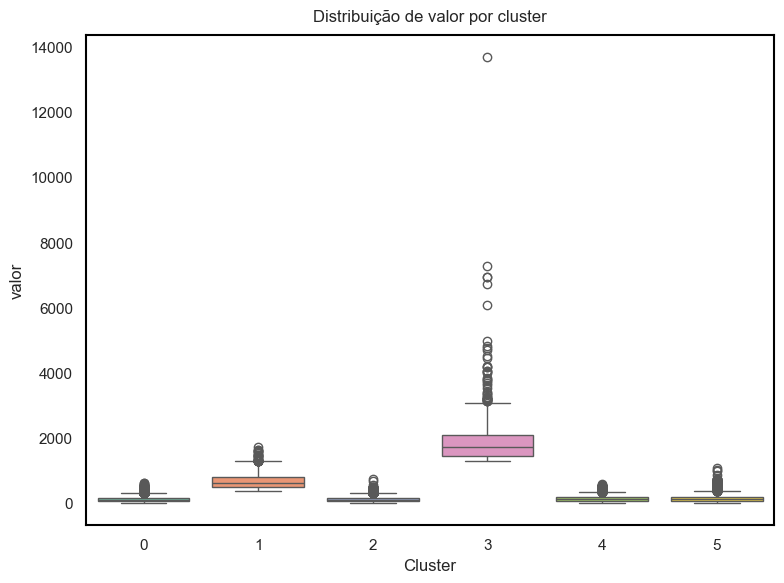

C:\Users\Eliakim\AppData\Local\Temp\ipykernel_15436\3618892919.py:78: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x="Cluster", y=var, data=df_clusters, palette="Set2")


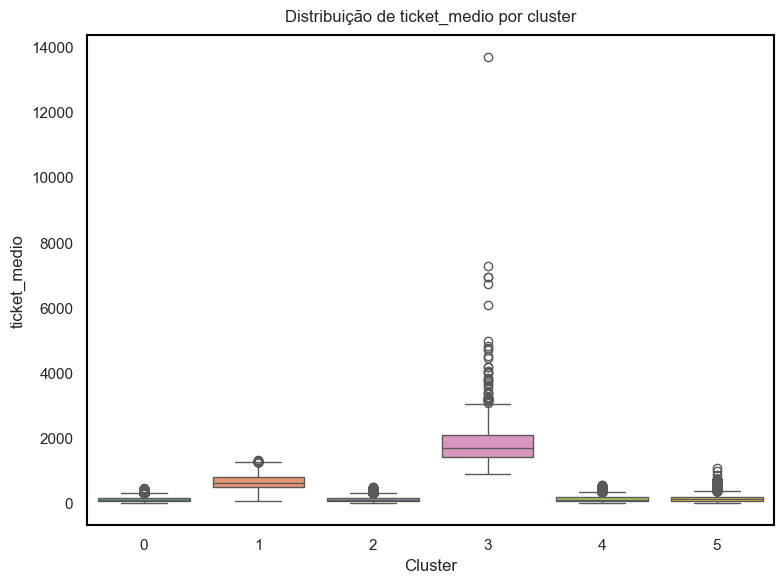

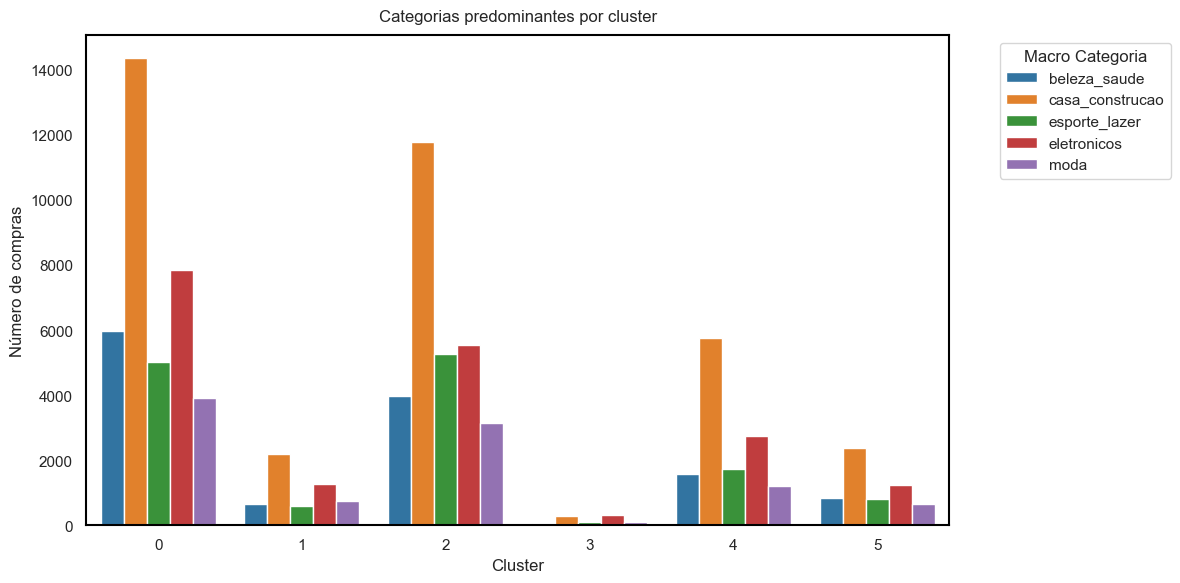

In [37]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import os
from sklearn.cluster import KMeans

# Pasta Downloads
download_path = os.path.expanduser("~/Downloads")

# Configuração global
plt.rcParams.update({
    "font.family": "Arial",
    "axes.edgecolor": "black",
    "axes.linewidth": 1.5,
    "axes.grid": False,
    "figure.facecolor": "white"
})

# -------------------------------
# 1. Rodar K-Means com 6 clusters
# -------------------------------
kmeans_final = KMeans(n_clusters=6, random_state=42)
labels = kmeans_final.fit_predict(X_scaled)

df_clusters = df_cliente.copy()
df_clusters["Cluster"] = labels

# -------------------------------
# 2. Estatísticas numéricas por cluster
# -------------------------------
cluster_summary = df_clusters.groupby("Cluster").agg({
    "recencia_dias": "mean",
    "frequencia": "mean",
    "valor": "mean",
    "ticket_medio": "mean"
}).round(2)

cluster_summary.to_csv(os.path.join(download_path, "resumo_clusters_numerico.csv"))

# -------------------------------
# 3. Top categorias por cluster
# -------------------------------
# Juntar clusters com items_customer
items_clusters = items_customer.merge(df_clusters[["customer_id","Cluster"]], on="customer_id")

# Agrupar por cluster e macro_categoria
top_categories = (
    items_clusters.groupby(["Cluster","macro_categoria"])
    .size()
    .reset_index(name="Compras")
    .sort_values(["Cluster","Compras"], ascending=[True,False])
)

# Selecionar top 3 categorias por cluster
top3_categories = top_categories.groupby("Cluster").head(3)

# Salvar em CSV
top3_categories.to_csv(os.path.join(download_path, "top3_macro_categorias_por_cluster.csv"), index=False)

print(top3_categories)

# Gráfico de barras mostrando categorias predominantes por cluster
plt.figure(figsize=(12,6))
sns.barplot(x="Cluster", y="Compras", hue="macro_categoria", data=top3_categories, palette="tab10")
plt.title("Top 3 macro categorias por cluster", fontsize=12, pad=10)
plt.xlabel("Cluster")
plt.ylabel("Número de compras")
plt.legend(title="Macro Categoria", bbox_to_anchor=(1.05, 1), loc="upper left")
plt.tight_layout()
plt.savefig(os.path.join(download_path, "top3_macro_categorias_clusters.png"), dpi=300)
plt.show()

# -------------------------------
# 4. Boxplots das variáveis numéricas
# -------------------------------
for var in ["recencia_dias", "frequencia", "valor", "ticket_medio"]:
    plt.figure(figsize=(8,6))
    sns.boxplot(x="Cluster", y=var, data=df_clusters, palette="Set2")
    plt.title(f"Distribuição de {var} por cluster", fontsize=12, pad=10)
    plt.xlabel("Cluster")
    plt.ylabel(var)
    plt.tight_layout()
    plt.savefig(os.path.join(download_path, f"boxplot_{var}_clusters.png"), dpi=300)
    plt.show()

# -------------------------------
# 5. Gráfico categorias por cluster
# -------------------------------
plt.figure(figsize=(12,6))
sns.countplot(x="Cluster", hue="macro_categoria", 
              data=items_clusters[items_clusters["macro_categoria"].isin(top3_categories["macro_categoria"].unique())],
              palette="tab10")
plt.title("Categorias predominantes por cluster", fontsize=12, pad=10)
plt.xlabel("Cluster")
plt.ylabel("Número de compras")
plt.legend(title="Macro Categoria", bbox_to_anchor=(1.05, 1), loc="upper left")
plt.tight_layout()
plt.savefig(os.path.join(download_path, "categorias_por_cluster.png"), dpi=300)
plt.show()